#Credit Card Fraud Detection
Link to the dataset: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

### Problem Statement :
With credit card use at an all-time high, automated fraud detection is essential to protect users and banks from billions in losses.

### Objective:
Develop a binary classification model that accurately distinguishes between genuine and fraudulent transactions. The primary technical focus is on handling extreme class imbalance to ensure high precision and recall.


### Dataset Features:
V1 - V28 : Numerical features that are a result of PCA transformation.

Time : Seconds elapsed between each transaction and the 1st transaction.

Amount : Transaction amount.

Class : Fraud or otherwise (1 or 0)


##Setup & Data Loading

In [13]:
# Load the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
import joblib
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, roc_auc_score
from sklearn.model_selection import cross_validate, StratifiedKFold
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline # for imbalanced datasets
from sklearn.neighbors import KNeighborsClassifier

# Load the dataset
df = pd.read_csv('creditcard.csv')

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [5]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## EDA

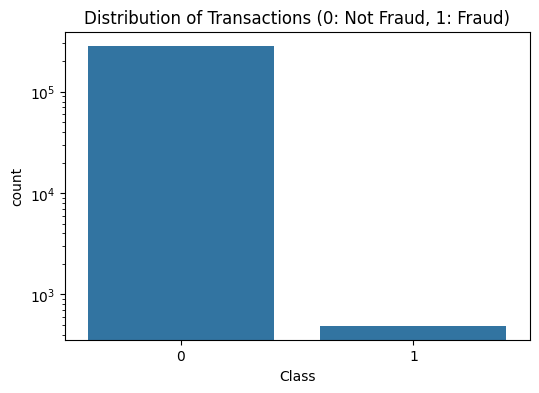

In [6]:
# Class Distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Class', legend=True)
plt.title('Distribution of Transactions (0: Not Fraud, 1: Fraud)')
plt.yscale('log') # Log scale because fraud is so tiny
plt.show()

In [7]:
df.Class.value_counts()

,count
Class,
0,284315
1,492


- The data is clearly highly unbalanced with majority of the transactions being **Not Fraud**.
- Due to highly **unbalanced** data, the classification model will bias its prediction towards the majority class, Not Fraud.
- Hence, data balancing becomes a crucial part in building a robust model.

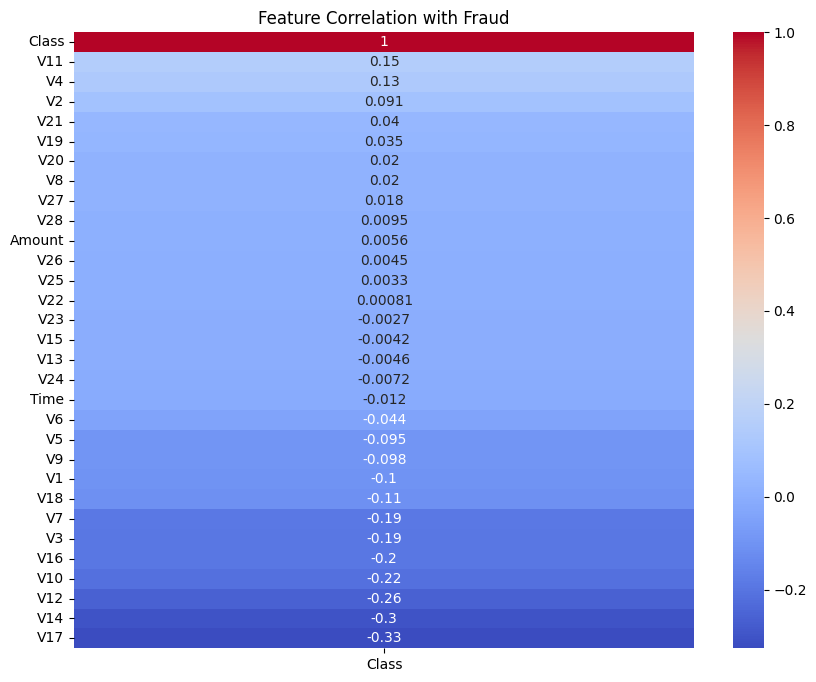

In [8]:
# Correlation with Class
plt.figure(figsize=(10,8))
corr = df.corr()
sns.heatmap(corr[['Class']].sort_values(by='Class', ascending=False), annot=True, cmap='coolwarm')
plt.title('Feature Correlation with Fraud')
plt.show();

## Split the data

We split BEFORE scaling or oversampling to prevent data leakage from the test set into the training process.

In [9]:
# Separate features and target
X = df.drop(['Class', 'Time'], axis=1) # Dropping Time as it's usually just a sequence
y = df['Class']

In [19]:
# Define the CV Strategy & Preprocessing Steps once
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scaler = StandardScaler()
smote = SMOTE(sampling_strategy=0.1, random_state=42)

# Define the different Models
# We start with Baseline (Logistic) and move to Advanced (RF, XGB)
models = {
    "LR": LogisticRegression(max_iter=1000),
    "RF": RandomForestClassifier(n_estimators=100, max_depth=7, n_jobs=-1, max_samples=0.5), # Trains on only 50% of data per tree
    "XGB": XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, tree_method='hist') # hist is much faster
}

In [20]:
results = []

# Try out different models
for name, clf in models.items():
    print(f"Training {name}...")

    # We build the pipeline dynamically for each classifier
    pipeline = ImbPipeline([
        ('scaler', scaler),
        ('smote', smote),
        ('classifier', clf)
    ])

    # cross_validate handles the split/fit/score
    cv_score = cross_validate(pipeline, X, y, cv=skf,
                              scoring=['recall', 'roc_auc', 'f1'],
                              n_jobs=-1)

    results.append({
        "Model": name,
        "Mean_Recall": cv_score['test_recall'].mean(),
        "Mean_AUC": cv_score['test_roc_auc'].mean(),
        "Mean F1 Score": cv_score['test_f1'].mean(),
        "Recall_Std": cv_score['test_recall'].std() # Shows stability
    })

Training LR...
Training RF...
Training XGB...


In [21]:
comparison_df = pd.DataFrame(results).sort_values(by='Mean_Recall', ascending=False)
print("\n--- Results ---")
comparison_df


--- Results ---


,Model,Mean_Recall,Mean_AUC,Mean F1 Score,Recall_Std
0,LR,0.851618,0.977715,0.554180,0.022722
2,XGB,0.841455,0.977801,0.793645,0.024490
1,RF,0.837394,0.980474,0.806650,0.014337


We select XGBoost because it offers the best balance of high Recall (84%) and high F1-score (0.79), while providing the low inference latency required for a production banking environment.


--- FINAL CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.65      0.86      0.74        98

    accuracy                           1.00     56962
   macro avg       0.82      0.93      0.87     56962
weighted avg       1.00      1.00      1.00     56962



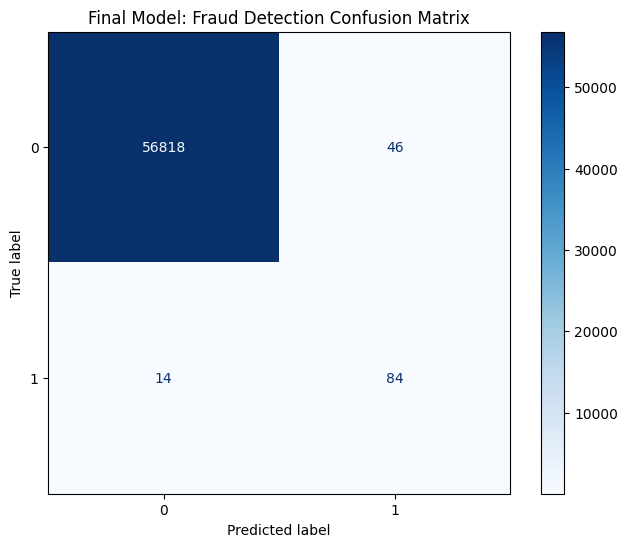

In [31]:
from sklearn.metrics import ConfusionMatrixDisplay

# Quick 80/20 Split for the Final Report
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Re-fit the winning XGBoost Pipeline on this split
final_pipeline = ImbPipeline([
    ('scaler', scaler),
    ('smote', smote),
    ('classifier', XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, tree_method='hist'))
])

final_pipeline.fit(X_train_final, y_train_final)

# Generate the classification report
print("\n--- FINAL CLASSIFICATION REPORT ---")
y_pred = final_pipeline.predict(X_test_final)
print(classification_report(y_test_final, y_pred))

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(final_pipeline, X_test_final, y_test_final, cmap='Blues', ax=ax)
plt.title('Final Model: Fraud Detection Confusion Matrix')
plt.show()


In [32]:
# Save the model for deployment
joblib.dump(final_pipeline, 'fraud_pipeline.pkl')


['fraud_pipeline.pkl']